# Airbnb európai szálláshelyek elemzése

Ebben a notebookban mesterséges intelligencia eszközök segítségével elemzünk Airbnb szállásadatokat – adatbetöltéstől a klaszterezésen át az ár-előrejelzésig.

### Mit fogunk csinálni?
1. Betöltjük és megvizsgáljuk a 10 európai várost tartalmazó adatbázist
2. **Gyors EDA** – az adatok vizualizálása az első lépésben
3. Feltárjuk az összefüggéseket korreláció-heatmap és boxplot diagramokkal
4. Log-transzformációval kezeljük az ár eloszlásának ferdeségét
5. **K-means klaszterezéssel** (tanítás nélküli AI) szegmentáljuk a budapesti szálláshelyeket
6. **Random Forest** modellel előrejelezzük az árakat
7. Cosine similarity alapján hasonló szállásokat ajánlunk *(opcionális)*

### Eszközök
- **pandas, numpy** – adatkezelés
- **matplotlib, seaborn** – vizualizáció
- **scikit-learn** – klaszterezés, gépi tanulás
- **Gemini** – kódgenerálás (vibe coding)

> **Vibe coding:** nem mi írjuk a kódot, hanem AI-jal generáltatjuk. Mi pedig értjük, futtatjuk és irányítjuk.

## 1. Telepítés és importok

Az első lépés a szükséges csomagok betöltése. Ezt a cellát mindig futtasd le először!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print('Csomagok sikeresen betöltve!')

Csomagok sikeresen betöltve!


## 2. Adatbetöltés

Az adatfájlt töltsd fel a Colab session-be (bal oldali fájlkezelő → feltöltés gomb),
vagy add meg a GitHub raw URL-t.

**A dataset oszlopai:**

| Oszlop | Tartalom |
|--------|----------|
| City | Város (10 európai főváros) |
| Price | Éjszakánkénti ár (EUR) |
| Day | Weekday / Weekend |
| Room Type | Private room / Entire home / Shared room |
| Superhost | Szupergazda-e? |
| Person Capacity | Max. vendégszám |
| Cleanliness Rating | Tisztasági értékelés |
| Guest Satisfaction | Összesített értékelés (0–100) |
| Bedrooms | Hálószobák száma |
| City Center (km) | Távolság a városközponttól |
| Metro Distance (km) | Távolság a legközelebbi metróhoz |
| Normalised Attraction Index | Látványosságok indexe (0–100) |

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely betölti az adatfájlt és kiírja az alapinformációkat!

Kontextus:
- A fájl neve: `airbnb_europe.csv`
- Írja ki a sorok és oszlopok számát
- Jelenítse meg az első 5 sort
- Írja ki az összes város nevét
- Ellenőrizze a hiányzó értékeket

*A kapott kódot másold be az alábbi cellába és futtasd le!*

In [4]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Adatbetöltés és alapinformációk

# 1. Betöltjük az airbnb_europe.csv fájlt
# Megjegyzés: Ellenőrizd, hogy a fájl neve pontosan ez-e a Colab fájlkezelőjében!
try:
    df = pd.read_csv('airbnb_europe.csv')
    print("Fájl sikeresen betöltve!\n")
except FileNotFoundError:
    print("Hiba: A 'airbnb_europe.csv' fájl nem található. Kérlek, töltsd fel a Colab-ba!")

# Ha a betöltés sikeres volt, jöhetnek a műveletek:
if 'df' in locals():
    # 2. Sorok és oszlopok száma
    print(f"Az adathalmaz {df.shape[0]} sorból és {df.shape[1]} oszlopból áll.")
    print("-" * 30)

    # 3. Első 5 sor megjelenítése
    print("Az első 5 sor:")
    display(df.head())
    print("-" * 30)

    # 4. Egyedi városok nevei
    # Feltételezve, hogy az oszlop neve 'city' vagy 'City'
    city_column = 'city' if 'city' in df.columns else 'City'
    if city_column in df.columns:
        unique_cities = df[city_column].unique()
        print(f"Egyedi városok ({len(unique_cities)} db):")
        print(unique_cities)
    else:
        print("Hiba: Nem található 'city' nevű oszlop.")
    print("-" * 30)

    # 5. Hiányzó értékek ellenőrzése oszloponként
    print("Hiányzó értékek száma oszloponként:")
    print(df.isnull().sum())

Fájl sikeresen betöltve!

Az adathalmaz 41714 sorból és 19 oszlopból áll.
------------------------------
Az első 5 sor:


,City,Price,Day,Room Type,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
0,Amsterdam,194.033698,Weekday,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473
1,Amsterdam,344.245776,Weekday,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928
2,Amsterdam,264.101422,Weekday,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700
3,Amsterdam,433.529398,Weekday,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565
4,Amsterdam,485.552926,Weekday,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677


------------------------------
Egyedi városok (9 db):
['Amsterdam' 'Athens' 'Barcelona' 'Berlin' 'Budapest' 'Lisbon' 'Paris'
 'Rome' 'Vienna']
------------------------------
Hiányzó értékek száma oszloponként:
City                           0
Price                          0
Day                            0
Room Type                      0
Shared Room                    0
Private Room                   0
Person Capacity                0
Superhost                      0
Multiple Rooms                 0
Business                       0
Cleanliness Rating             0
Guest Satisfaction             0
Bedrooms                       0
City Center (km)               0
Metro Distance (km)            0
Attraction Index               0
Normalised Attraction Index    0
Restraunt Index                0
Normalised Restraunt Index     0
dtype: int64


## 2.5 Gyors EDA – az adatok első pillantásra

Mielőtt bármit szűrünk vagy transzformálunk, nézzük meg az adatbázist vizuálisan.
Ez a két diagram megmutatja, **miért** lesz szükség outlier szűrésre és log-transzformációra.

**Amit keresünk:**
- Melyik városban drágábbak a szállások?
- Milyen az ár eloszlása? Szimmetrikus, vagy van néhány extrém magas érték?

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely elkészíti az EDA vizualizációkat!

Kontextus:
- `df` a betöltött DataFrame
- **1. diagram:** barplot – átlagos `Price` városonként, csökkenő sorrendben, `palette='Set3'`, méret 10×5
- **2. diagram:** hisztogram – `Price` nyers eloszlása, `bins=60`, méret 10×4

*A kapott kódot másold be az alábbi cellába és futtasd le!*

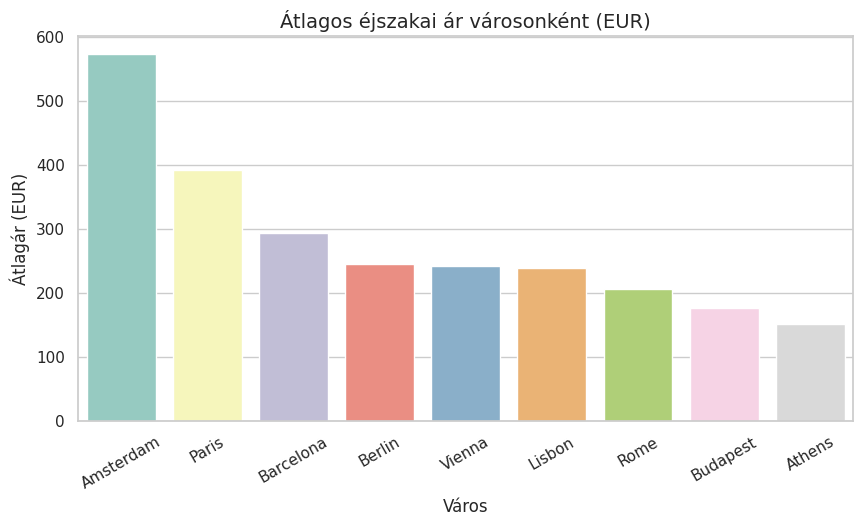

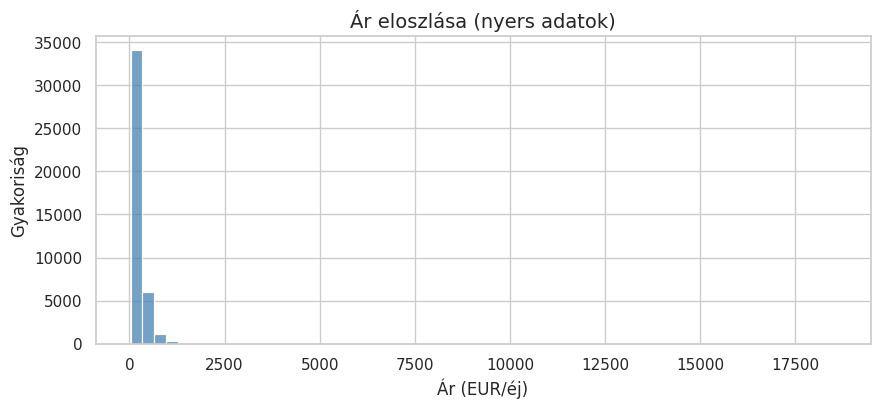

In [6]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Gyors EDA: átlagárak városonként + ár hisztogram

# Feltételezzük, hogy az oszlopnevek: 'City' és 'Price' (vagy ahogy a fájlban szerepelnek)
# Ha nem vagy biztos benne, futtasd le a print(df.columns) parancsot!

# 1. BARPLOT: Átlagos ár városonként
plt.figure(figsize=(10, 5))

# Kiszámoljuk az átlagot a 'Price' oszlop alapján, városok szerint csoportosítva
# A sort_values gondoskodik a csökkenő sorrendről
avg_prices = df.groupby('City')['Price'].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_prices.index,
    y=avg_prices.values,
    palette='Set3'
)

plt.title('Átlagos éjszakai ár városonként (EUR)', fontsize=14)
plt.xlabel('Város')
plt.ylabel('Átlagár (EUR)')
plt.xticks(rotation=30)
plt.show()

# --- 2. HISZTOGRAM: A 'Price' oszlop nyers eloszlása ---
plt.figure(figsize=(10, 4))

sns.histplot(
    df['Price'],
    bins=60,
    color='steelblue'
)

plt.title('Ár eloszlása (nyers adatok)', fontsize=14)
plt.xlabel('Ár (EUR/éj)')
plt.ylabel('Gyakoriság')
plt.show()

## 3. Alapstatisztikák és outlier szűrés

Az ár eloszlása erősen jobbra ferde – néhány extrém árú luxusszálláshely torzítja az elemzést.
A 99. percentilis feletti rekordokat eltávolítjuk.

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely elvégzi az alapstatisztikákat és az outlier szűrést!

Kontextus:
- `df` a betöltött DataFrame
- Írja ki a `describe()` eredményét
- Számítsa ki a 99. percentilis értéket az árra
- Szűrje ki az e feletti sorokat
- Írja ki, hány sor maradt és mi a szűrési határ (EUR/éj)

*A kapott kódot másold be az alábbi cellába és futtasd le!*

--- Alapstatisztikák (Price) ---
count    41714.000000
mean       260.094423
std        279.408493
min         34.779339
25%        144.016085
50%        203.819274
75%        297.373358
max      18545.450285
Name: Price, dtype: float64
------------------------------


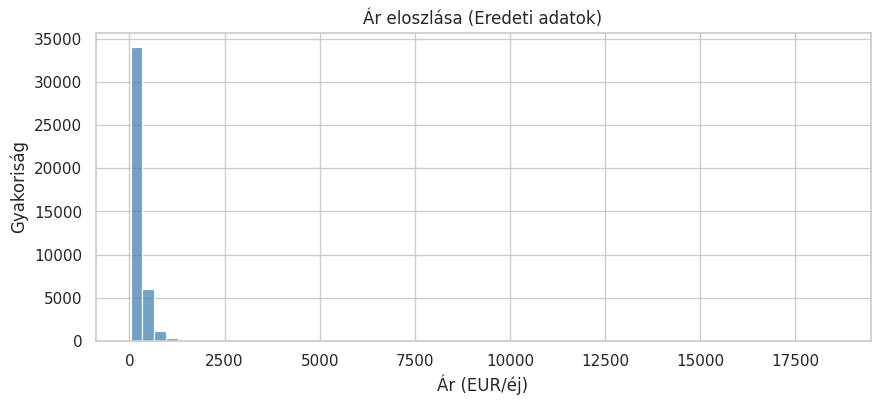

Szűrési határ (99. percentilis): 1044.69 EUR/éj
Eredeti sorok száma: 41714
Sorok száma szűrés után: 41304
Eltávolított sorok: 410


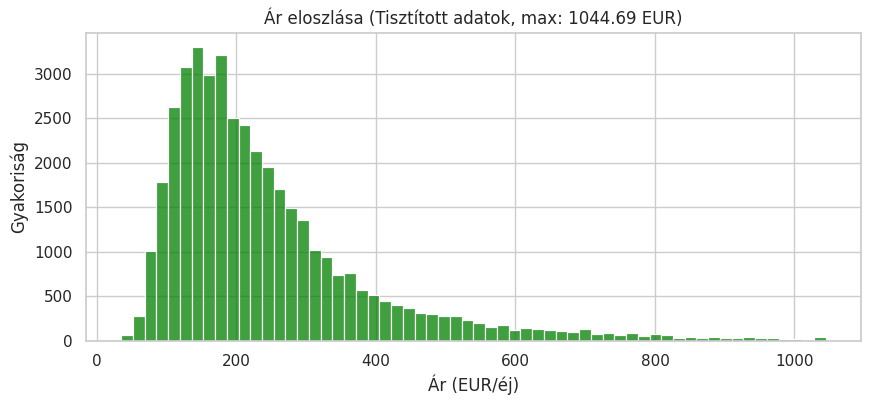

In [7]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Alapstatisztikák és outlier szűrés

# 1. Alapstatisztikák kiíratása
print("--- Alapstatisztikák (Price) ---")
print(df['Price'].describe())
print("-" * 30)

# 2. Eredeti hisztogram (nyers adatok)
plt.figure(figsize=(10, 4))
sns.histplot(df['Price'], bins=60, color='steelblue')
plt.title('Ár eloszlása (Eredeti adatok)')
plt.xlabel('Ár (EUR/éj)')
plt.ylabel('Gyakoriság')
plt.show()

# 3. Kiugró értékek kiszűrése (99. percentilis felettiek elhagyása)
# Ez azt jelenti, hogy a legdrágább 1%-ot levágjuk.
limit = df['Price'].quantile(0.99)
df_filtered = df[df['Price'] <= limit]

# 4. Információk kiírása
print(f"Szűrési határ (99. percentilis): {limit:.2f} EUR/éj")
print(f"Eredeti sorok száma: {len(df)}")
print(f"Sorok száma szűrés után: {len(df_filtered)}")
print(f"Eltávolított sorok: {len(df) - len(df_filtered)}")

# 5. Új hisztogram a tisztított adatokkal
plt.figure(figsize=(10, 4))
sns.histplot(df_filtered['Price'], bins=60, color='green')
plt.title(f'Ár eloszlása (Tisztított adatok, max: {limit:.2f} EUR)')
plt.xlabel('Ár (EUR/éj)')
plt.ylabel('Gyakoriság')
plt.show()


## 4. Korreláció-heatmap

A heatmap megmutatja, melyik változók függnek össze egymással.
Az értékek –1 és +1 között mozognak:
- **+1** → erős pozitív összefüggés (ha az egyik nő, a másik is nő)
- **–1** → erős negatív összefüggés (ha az egyik nő, a másik csökken)
- **0** → nincs összefüggés

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely elkészíti a korreláció-heatmapet!

Kontextus:
- `df` a szűrt DataFrame
- Csak numerikus oszlopokat szerepeltess
- Seaborn heatmap, `annot=True`, `cmap='RdBu_r'`, `vmin=-1`, `vmax=1`
- Méret: 14×9

*A kapott kódot másold be az alábbi cellába és futtasd le!*

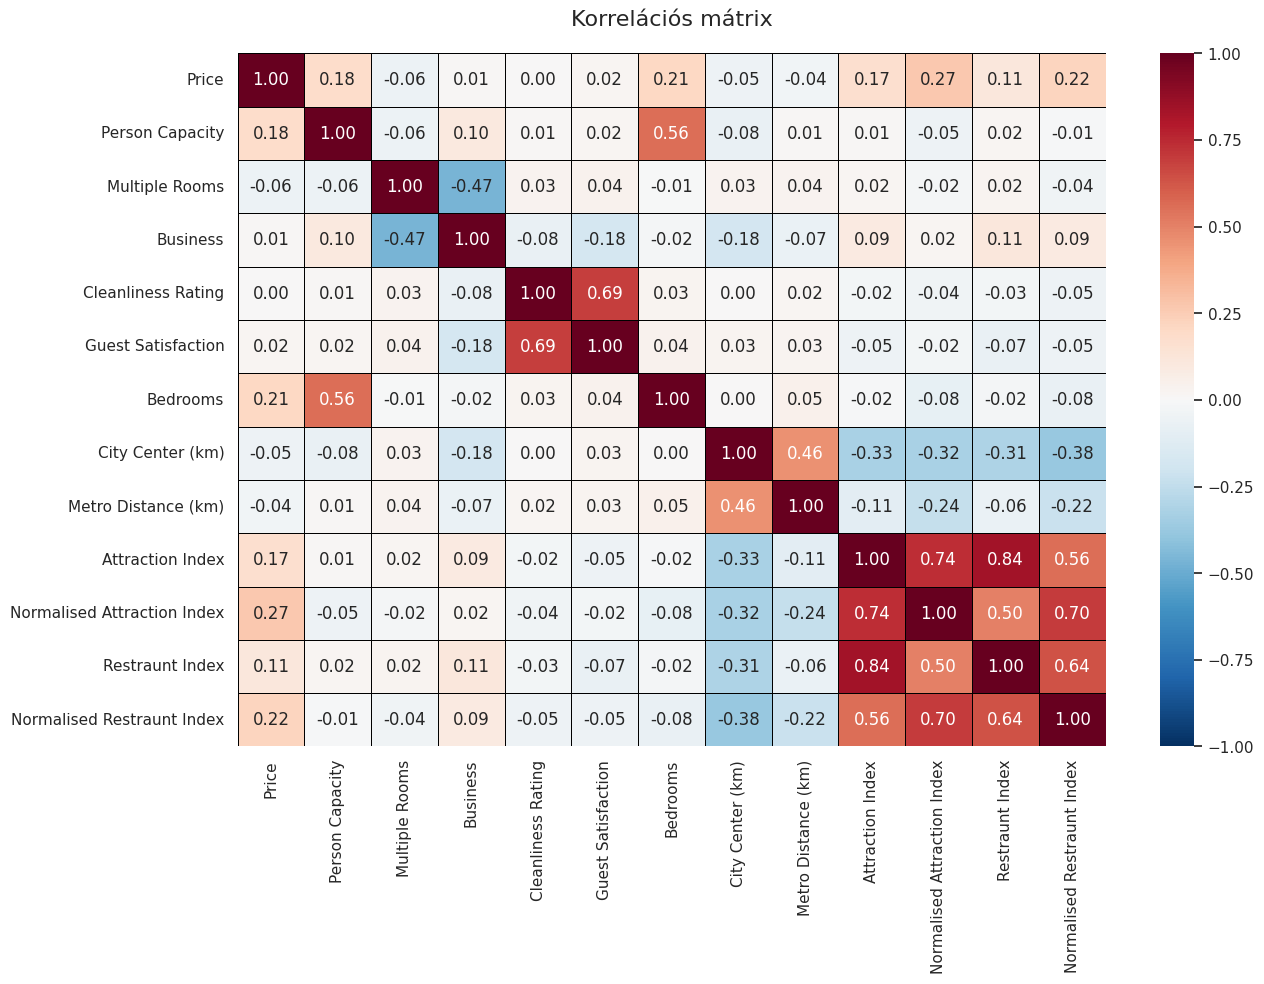

In [8]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Korreláció-heatmap

# 1. Csak a numerikus oszlopok kiválasztása
numeric_df = df.select_dtypes(include=['number'])

# 2. Korrelációs mátrix kiszámítása
corr_matrix = numeric_df.corr()

# 3. Heatmap elkészítése
plt.figure(figsize=(14, 9))

sns.heatmap(
    corr_matrix,
    annot=True,          # Értékek kiírása a cellákba
    fmt=".2f",           # Két tizedesjegy pontosság
    cmap='RdBu_r',       # Piros-Kék színskála (reverz, hogy a pozitív legyen kék/piros függően az ízléstől)
    vmin=-1,             # Minimum érték a skálán
    vmax=1,              # Maximum érték a skálán
    linewidths=0.5,      # Cellák közötti vonalvastagság
    linecolor='black'    # Vonalak színe
)

plt.title('Korrelációs mátrix', fontsize=16, pad=20)
plt.show()

## 5. Ár eloszlás városonként – log-transzformáció

A nyers ár eloszlása miatt a KDE grafikonon a városok alig különböztethetők meg.
A **log10-transzformáció** összenyomja a nagy értékeket és szétnyújtja a kis értékeket,
így az eloszlások összehasonlíthatóvá válnak.

Például: 100 EUR → 2.0, 1000 EUR → 3.0, 10 000 EUR → 4.0

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely elkészíti a log-transzformált ár KDE diagramot!

Kontextus:
- `df` a szűrt DataFrame
- Hozz létre egy `df_log` másolatot, ahol `Price` = `np.log10(df['Price'])`
- `sns.displot` KDE diagram, `hue='City'`, `fill=True`
- Cím: `'Ár eloszlás városonként (log10 skála)'`

*A kapott kódot másold be az alábbi cellába és futtasd le!*

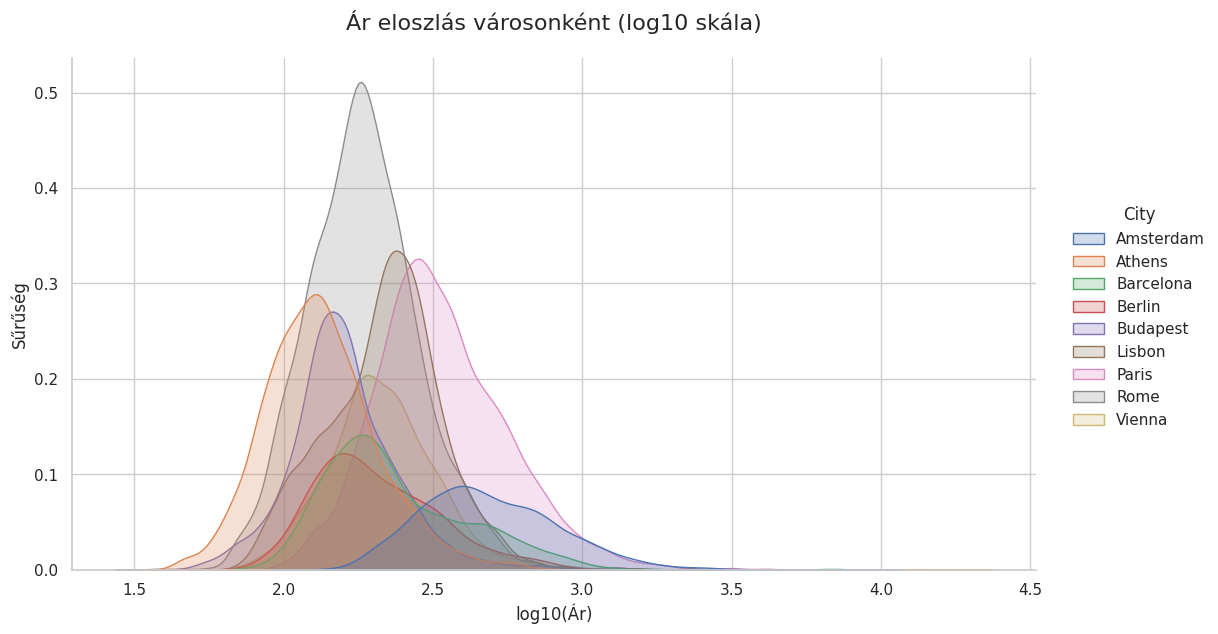

In [11]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Log-transzformált ár KDE diagram városonként

# 1. Másolat készítése a DataFrame-ről
df_log = df.copy()

# 2. A 'Price' oszlop logaritmizálása (10-es alapú logaritmus)
df_log['Price'] = np.log10(df['Price'])

# 3. sns.displot létrehozása KDE diagramként
g = sns.displot(
    data=df_log,
    x='Price',
    hue='City',
    kind='kde',
    fill=True,
    height=6,
    aspect=1.8
)

# 4. Cím és tengelyfeliratok beállítása
g.set_axis_labels('log10(Ár)', 'Sűrűség')
plt.title('Ár eloszlás városonként (log10 skála)', fontsize=16, pad=20)

plt.show()

## 6. Összefüggés-vizsgálatok (binning)

Három kérdést vizsgálunk boxplot diagramokkal:
1. Befolyásolja-e a **tisztaság** a vendégelégedettséget?
2. Csökken-e az **ár** a városközponttól távolodva?
3. Magasabb ár jár-e együtt jobb **értékeléssel**?

A **binning** technika folytonos változókat (pl. távolság km-ben) kategóriákra oszt
(pl. 0–3 km, 3–6 km stb.), így boxplottal vizualizálhatók.

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely elkészíti a három boxplot diagramot!

Kontextus:
- `df` a szűrt DataFrame, `df_log` a log-transzformált verzió
- **1. diagram:** `x='Cleanliness Rating'`, `y='Guest Satisfaction'`
- **2. diagram:** `City Center (km)` binning 3 km-es lépésekkel (0–3, 3–6, … 24–27 km),
  `x=bin`, `y=log10(Price)`
- **3. diagram:** `Guest Satisfaction` binning 10-es lépésekkel (0–10, 10–20, … 90–100),
  `x=bin`, `y=log10(Price)`
- Minden diagramnál `palette='Set3'`, méret: 12×5

*A kapott kódot másold be az alábbi cellába és futtasd le!*

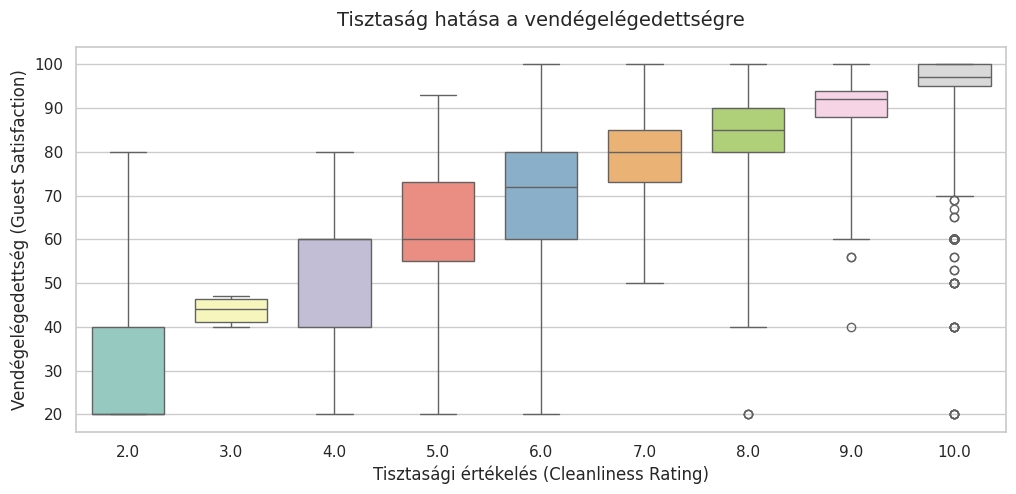

In [12]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Összefüggés-vizsgálatok: cleanliness, távolság, elégedettség

# A diagram méretének beállítása
plt.figure(figsize=(12, 5))

# Boxplot létrehozása
sns.boxplot(
    data=df,
    x='Cleanliness Rating',
    y='Guest Satisfaction',
    palette='Set3',
    width=0.7,
    whis=5 # A "bajusz" hossza (5-szöröse az interkvartilis terjedelemnek)
)

# Cím és stílus finomítása
plt.title('Tisztaság hatása a vendégelégedettségre', fontsize=14, pad=15)
plt.xlabel('Tisztasági értékelés (Cleanliness Rating)')
plt.ylabel('Vendégelégedettség (Guest Satisfaction)')

plt.show()

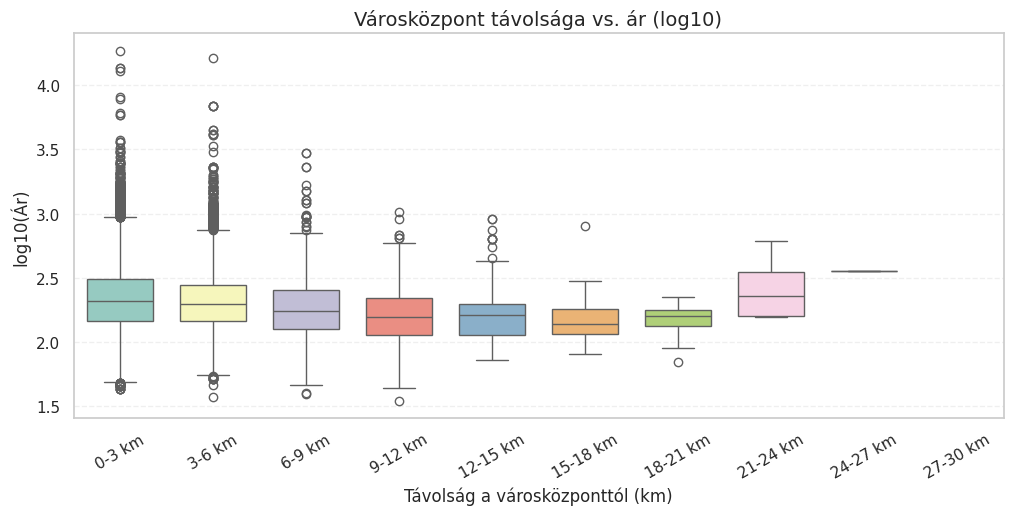

In [17]:
# 1. Kategóriák (bin-ek) létrehozása 0-tól 27-ig, 3 km-es lépésközzel
# A range(0, 31, 3) a határokat adja meg: [0, 3, 6, ..., 30]
bins = list(range(0, 31, 3))
labels = [f"{bins[i]}-{bins[i+1]} km" for i in range(len(bins)-1)]

# 2. Alkalmazzuk a vágást a 'City Center (km)' oszlopra
# Fontos: pontosan írjuk le az oszlopnevet, ahogy megadtad!
df['dist_bin'] = pd.cut(df['City Center (km)'], bins=bins, labels=labels, include_lowest=True)

# 3. Vizualizáció: Boxplot logaritmusos árral
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x='dist_bin',
    y=np.log10(df['Price']),
    palette='Set3',
    width=0.7
)

# 4. Formázás
plt.title('Városközpont távolsága vs. ár (log10)', fontsize=14)
plt.xlabel('Távolság a városközponttól (km)')
plt.ylabel('log10(Ár)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

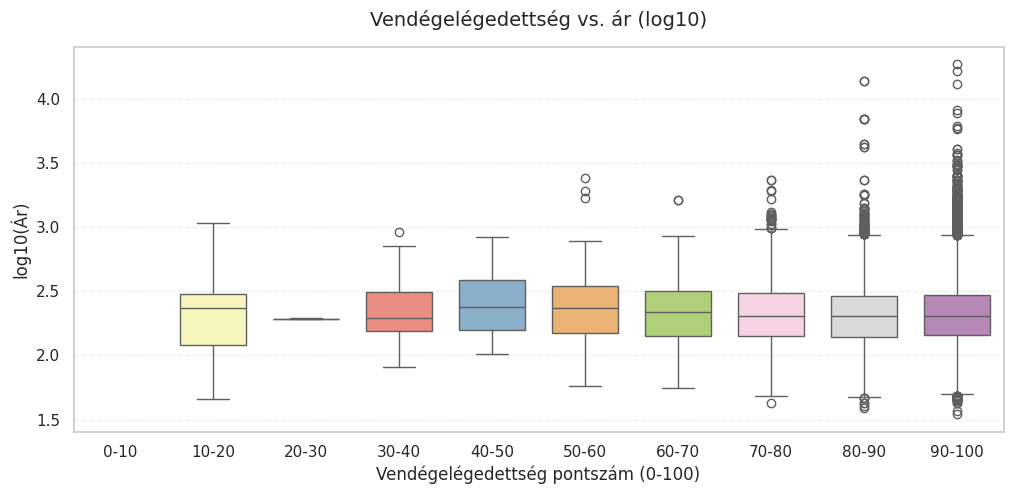

In [18]:
# 1. Kategóriák (bin-ek) létrehozása 0-tól 100-ig, 10-es lépésközzel
# A range(0, 101, 10) eredménye: [0, 10, 20, ..., 100]
sat_bins = list(range(0, 101, 10))
sat_labels = [f"{sat_bins[i]}-{sat_bins[i+1]}" for i in range(len(sat_bins)-1)]

# Alkalmazzuk a vágást a 'Guest Satisfaction' oszlopra
# Az include_lowest=True biztosítja, hogy a 0 is bekerüljön az első kategóriába
df['sat_bin'] = pd.cut(df['Guest Satisfaction'], bins=sat_bins, labels=sat_labels, include_lowest=True)

# 2. Vizualizáció: Boxplot logaritmusos árral
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x='sat_bin',
    y=np.log10(df['Price']),
    palette='Set3',
    width=0.7
)

# 3. Formázás
plt.title('Vendégelégedettség vs. ár (log10)', fontsize=14, pad=15)
plt.xlabel('Vendégelégedettség pontszám (0-100)')
plt.ylabel('log10(Ár)')

# Rács hozzáadása a könnyebb leolvashatóságért
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## 7. K-means klaszterezés – Budapest

A K-means tanítás nélküli (unsupervised) algoritmus: előre megcímkézett adat nélkül fedez fel csoportokat a hasonlóságok alapján. Egyszerre veszi figyelembe az összes változót – ár, távolság, elégedettség, hálószobák száma stb. – így üzleti szegmensek azonosíthatók (pl. budget, prémium, nagy kapacitású). A folytonos változókat standardizálni kell, mert eltérő skálán vannak; a kategorikus oszlopokat one-hot encodinggal bináris (0/1) értékekké alakítjuk.

**Lépések:**
1. Szűrjük Budapest adatait
2. Kategóriaváltozókat kódolunk (one-hot encoding)
3. Folytonos változókat standardizálunk (`StandardScaler`)
4. Elbow method – meghatározzuk az optimális K értéket
5. K-means futtatása, klaszter profilok
6. PCA vizualizáció – 2D-ben ábrázoljuk a klasztereket

> **A PCA két tengelye nem közvetlen változók** – a variancia irányait mutatják.
> Az a lényeg, hogy a **színek szétválnak-e**: ez jelzi, hogy az algoritmus valódi csoportokat talált.

---
**Prompt feladat – 1. rész: adatelőkészítés és elbow**

Fogalmazz meg egy promptot a Gemini számára, amely elvégzi a Budapest szűrést,
az adatelőkészítést és az elbow method kirajzolását!

Kontextus:
- `df` a teljes szűrt DataFrame
- Szűrj Budapest adataira: `df[df['City'] == 'Budapest']`
- One-hot encoding a kategorikus oszlopokra (`pd.get_dummies`), bool → int8 konverzió
- `StandardScaler` a folytonos numerikus oszlopokra
- Elbow method: K = 2–15, inertia görbe

*A kapott kódot másold be az alábbi cellába és futtasd le!*

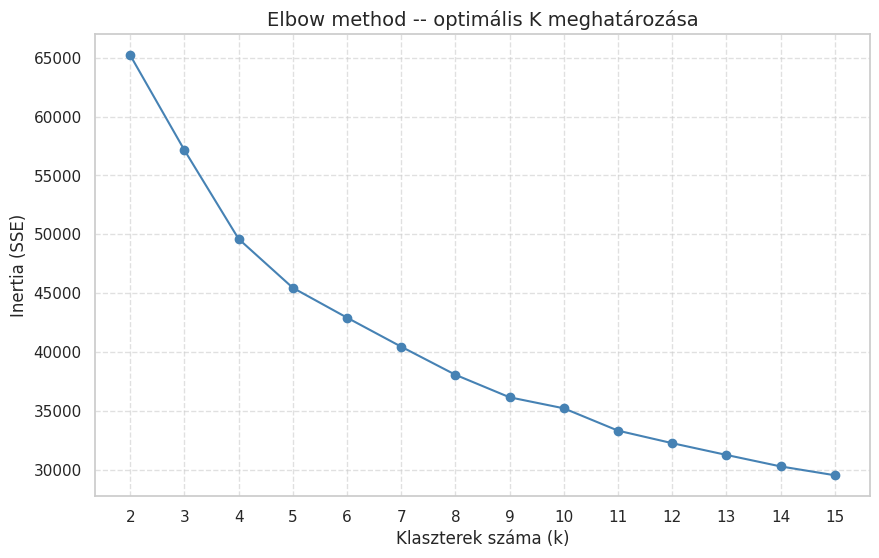

In [20]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Budapest szűrés, adatelőkészítés, elbow method

# 1. Budapesti adatok szűrése
df_bp = df[df['City'] == 'Budapest'].copy()

# 2. Csak a releváns oszlopok kiválasztása (numerikus + kategorikus)
# Eltávolítjuk a City oszlopot, hiszen az most mindenhol 'Budapest'
features = df_bp.drop(columns=['City', 'dist_bin', 'sat_bin'], errors='ignore')

# 3. One-hot encoding a kategorikus oszlopokra
df_encoded = pd.get_dummies(features, drop_first=True)

# 4. Bool oszlopok konvertálása int8-ra
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype('int8')

# 5. Adatok standardizálása
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# 6. Elbow method: KMeans futtatása K=2..15
inertia = []
K_range = range(2, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 7. Vizualizáció
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='steelblue')
plt.title('Elbow method -- optimális K meghatározása', fontsize=14)
plt.xlabel('Klaszterek száma (k)')
plt.ylabel('Inertia (SSE)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
**Prompt feladat – 2. rész: K-means és PCA vizualizáció**

Az elbow görbe alapján válaszd ki az optimális K értéket, majd fogalmazz meg
egy promptot a Gemini számára a klaszterezés befejezéséhez!

Kontextus:
- `X_scaled` a standardizált mátrix, `df_bp` a budapesti DataFrame
- `KMeans(n_clusters=K, n_init='auto', random_state=42)`
- Klaszter profilok: csoportonkénti átlagok a főbb változókra
  (Price, Guest Satisfaction, City Center (km), Bedrooms)
- PCA 2 komponensre, scatter plot klaszterszín szerint

*A kapott kódot másold be az alábbi cellába és futtasd le!*

--- Budapesti Klaszter Profilok (Átlagok) ---
              Price  Guest Satisfaction  City Center (km)  Bedrooms
cluster                                                            
0        111.528190           92.861765          2.012784  1.020588
1        179.276356           94.633739          2.182371  1.121581
2        109.834660           94.678082          9.079804  1.280822
3        194.001870           94.866279          0.745186  1.088501
4        126.830447           97.571429          4.336207  1.000000
------------------------------


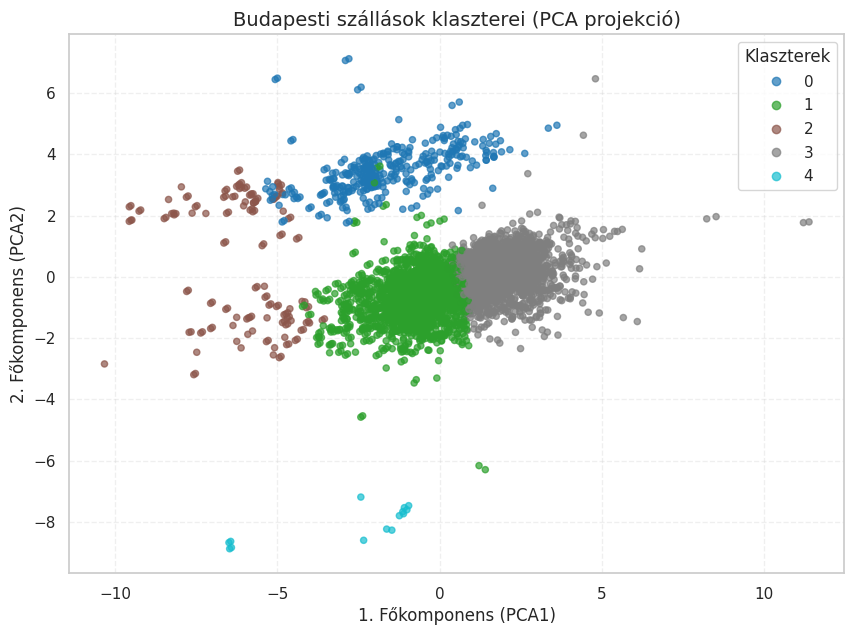

In [21]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# K-means futtatás, klaszter profilok, PCA vizualizáció

# 1. KMeans futtatása a kért paraméterekkel
kmeans = KMeans(n_clusters=5, n_init='auto', random_state=42)
df_bp['cluster'] = kmeans.fit_predict(X_scaled)

# 2. Klaszter profilok kiszámítása (csoportonkénti átlagok)
print("--- Budapesti Klaszter Profilok (Átlagok) ---")
profile_cols = ['Price', 'Guest Satisfaction', 'City Center (km)', 'Bedrooms']
# Csak azokat az oszlopokat használjuk, amik tényleg léteznek
available_cols = [c for c in profile_cols if c in df_bp.columns]
cluster_profiles = df_bp.groupby('cluster')[available_cols].mean()
print(cluster_profiles)
print("-" * 30)

# 3. PCA dimenziócsökkentés a vizualizációhoz
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Vizualizáció: Scatter plot PCA projekcióval
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_bp['cluster'],
    cmap='tab10',
    s=20,
    alpha=0.7
)

# Jelmagyarázat hozzáadása
plt.legend(*scatter.legend_elements(), title="Klaszterek")

plt.title('Budapesti szállások klaszterei (PCA projekció)', fontsize=14)
plt.xlabel('1. Főkomponens (PCA1)')
plt.ylabel('2. Főkomponens (PCA2)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 8. Ár-előrejelzés – Random Forest (Budapest)

A **Random Forest** egy döntési fák sokaságából álló ensemble modell.
Most arra tanítjuk, hogy a szálláshely jellemzői alapján megjósolja az árat.

**Értékelési metrikák:**
- **MAE** (Mean Absolute Error) – átlagos abszolút hiba EUR-ban
- **RMSE** (Root Mean Squared Error) – a nagy hibákat jobban bünteti
- **R²** – mennyit magyaráz meg a modell a variabilitásból (0–1, magasabb a jobb)

**Feature importance:** megmutatja, melyik változó befolyásolja leginkább az árat.

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely felépíti és értékeli a Random Forest modellt!

Kontextus:
- `df_bp` a budapesti DataFrame (one-hot kódolt, az előző feladatból)
- Cél változó: `Price`
- Train/test split: 80/20, `random_state=42`
- `RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)`
- Írja ki a Train és Test MAE, RMSE, R² értékeket
- Készítsen top 15 feature importance barplot diagramot (vízszintes)

*A kapott kódot másold be az alábbi cellába és futtasd le!*

--- Modell Teljesítmény ---
Tanító halmaz - MAE: 15.47, RMSE: 37.24, R2: 0.91
Teszt halmaz - MAE: 42.85, RMSE: 93.88, R2: 0.60
------------------------------


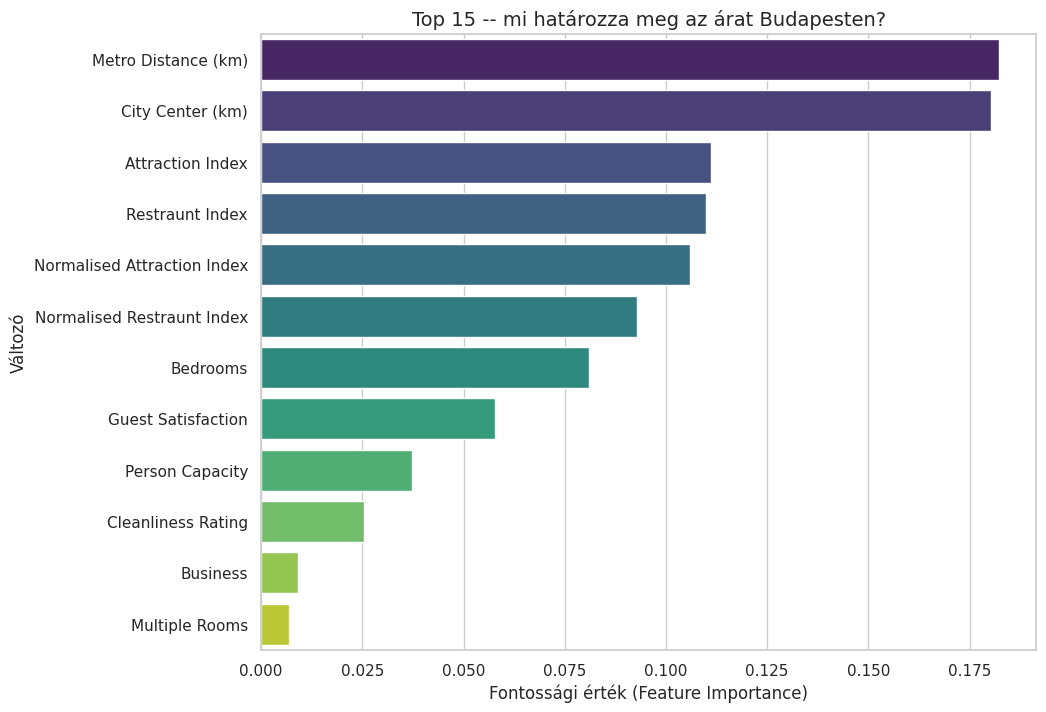

In [22]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Random Forest ár-előrejelzés, metrikák, feature importance

# 1. Előkészítés: Csak numerikus oszlopok használata
# (A korábbi lépésekből a df_bp már tartalmazza a dummy változókat)
X = df_bp.select_dtypes(include=[np.number]).drop(columns=['Price', 'cluster'], errors='ignore')
y = df_bp['Price']

# 2. Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modell tanítása (500 fa, minden CPU mag használata)
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 4. Predikció és kiértékelés
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("--- Modell Teljesítmény ---")
evaluate(y_train, y_train_pred, "Tanító halmaz")
evaluate(y_test, y_test_pred, "Teszt halmaz")
print("-" * 30)

# 5. Feature Importance - Top 15
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 -- mi határozza meg az árat Budapesten?', fontsize=14)
plt.xlabel('Fontossági érték (Feature Importance)')
plt.ylabel('Változó')
plt.show()

## 9. Hasonló szállások ajánlója *(opcionális)*

> Ez a feladat opcionális – ha az idő engedi, vagy házi projektként.

A **cosine similarity** két vektor közötti szög koszinuszát méri.
Ha két szálláshely numerikus jellemzői hasonlók (ár, értékelés, elhelyezkedés stb.),
a köztük lévő szög kicsi → a koszinusz értéke 1-hez közelít.

Az ajánló logikája:
1. Minden szálláshelyet egy numerikus vektor reprezentál
2. A referencia szálláshely vektorát összehasonlítjuk az összes többivel
3. A legmagasabb hasonlósági értékű 5 szállást ajánljuk

**Továbbfejlesztési irány – embedding-alapú ajánló:**
A mostani megközelítés numerikus jellemzőkön dolgozik.
A modern ajánlórendszerek szöveges leírásokból nyelvi modell segítségével
**beágyazási vektorokat (embeddings)** generálnak, és szemantikai hasonlóságot mérnek.
Ehhez a `sentence-transformers` könyvtár használható Colabon, API kulcs nélkül
(`paraphrase-multilingual-MiniLM` modell) – ez a házi projekt egyik lehetséges iránya.

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely felépíti a cosine similarity ajánlót!

Kontextus:
- `df` a teljes szűrt DataFrame (mind a 10 város)
- Feature-ök: `Price`, `Guest Satisfaction`, `City Center (km)`,
  `Bedrooms`, `Normalised Attraction Index`, `Metro Distance (km)`
- Standardizáld a feature-öket `StandardScaler`-rel
- Írj egy `ajanlj(idx, top_n=5)` függvényt, amely kiírja a referencia szállást
  és a top 5 leghasonlóbbat (Város, Room Type, Ár, Km, Értékelés, Hasonlóság)
- Teszteld egy budapesti és egy párizsi szállásra

*A kapott kódot másold be az alábbi cellába és futtasd le!*

In [23]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Cosine similarity ajánló

# 1. Feature-ök kiválasztása az ajánláshoz
features_list = [
    'Price', 'Guest Satisfaction', 'City Center (km)',
    'Bedrooms', 'Normalised Attraction Index', 'Metro Distance (km)'
]

# Biztosítjuk, hogy ne legyen hiányzó érték (ha van, kitöltjük mediánnal)
X_rec = df[features_list].fillna(df[features_list].median())

# 2. Standardizálás (fontos, hogy a távolságok ne torzuljanak)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rec)

# 3. Az ajánló függvény
def ajanlj(idx, top_n=5):
    # Kiszámoljuk a hasonlóságot a választott sor és az összes többi között
    query_vec = X_scaled[idx].reshape(1, -1)
    similarities = cosine_similarity(query_vec, X_scaled).flatten()

    # Sorba rendezzük és kivesszük a top_n eredményt (magát az elemet kihagyva)
    # Az argsort a legkisebbtől rendez, ezért a végéről vesszük az elemeket
    related_indices = similarities.argsort()[-(top_n+1):-1][::-1]

    # Kiírandó oszlopok
    cols_to_show = ['City', 'Room Type', 'Price', 'City Center (km)', 'Guest Satisfaction']

    print(f"--- REFERENCIA SZÁLLÁS (Index: {idx}) ---")
    print(df.loc[idx, cols_to_show].to_frame().T)
    print("\n" + "="*50 + "\n")

    print(f"--- TOP {top_n} AJÁNLOTT SZÁLLÁS ---")
    recommendations = df.loc[related_indices, cols_to_show].copy()
    recommendations['Similarity'] = similarities[related_indices]
    print(recommendations)

# 4. Tesztelés
# Keressünk egy budapesti és egy párizsi indexet
try:
    bp_idx = df[df['City'] == 'Budapest'].index[0]
    paris_idx = df[df['City'] == 'Paris'].index[0]

    print("TESZT 1: BUDAPEST")
    ajanlj(bp_idx)
    print("\n" + "*"*80 + "\n")

    print("TESZT 2: PÁRIZS")
    ajanlj(paris_idx)
except IndexError:
    print("Hiba: Nem található Budapest vagy Párizs az adatok között.")

TESZT 1: BUDAPEST
--- REFERENCIA SZÁLLÁS (Index: 12677) ---
           City        Room Type       Price City Center (km)  \
12677  Budapest  Entire home/apt  238.990459         0.359355   

      Guest Satisfaction  
12677               99.0  


--- TOP 5 AJÁNLOTT SZÁLLÁS ---
            City        Room Type       Price  City Center (km)  \
38573     Vienna  Entire home/apt  240.048617          0.216185   
40234     Vienna  Entire home/apt  260.150060          0.216192   
8205   Barcelona     Private room  237.158750          0.912354   
39107     Vienna  Entire home/apt  240.048617          0.279310   
14881   Budapest  Entire home/apt  265.309959          0.291527   

       Guest Satisfaction  Similarity  
38573               100.0    0.999054  
40234               100.0    0.998391  
8205                 97.0    0.997654  
39107                98.0    0.996654  
14881               100.0    0.996292  

******************************************************************************